In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.cm import get_cmap
import folium

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
def label_rfm_total(score_total):
    if score_total >= 11:
        return 'Très bons clients'
    elif score_total >= 9:
        return 'Bons clients'
    elif score_total == 8:
        return 'Clients tièdes'
    elif score_total == 7:
        return 'Nouveaux clients'
    elif 4 <= score_total <= 6:
        return 'À risque'
    else:
        return 'Inactifs'

In [3]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [4]:
df = pd.read_csv("query_results.csv")

## DATA EXPLORATION

In [5]:
print(len(df["customer_id"].unique()))
print(len(df["customer_unique_id"].unique()))

97906
94703


In [6]:
set(df["order_status"])

{'approved', 'created', 'delivered', 'invoiced', 'shipped'}

In [7]:
df["order_date"].min(), df["order_date"].max()

('2016-09-04 21:15:19', '2018-09-03 09:06:57')

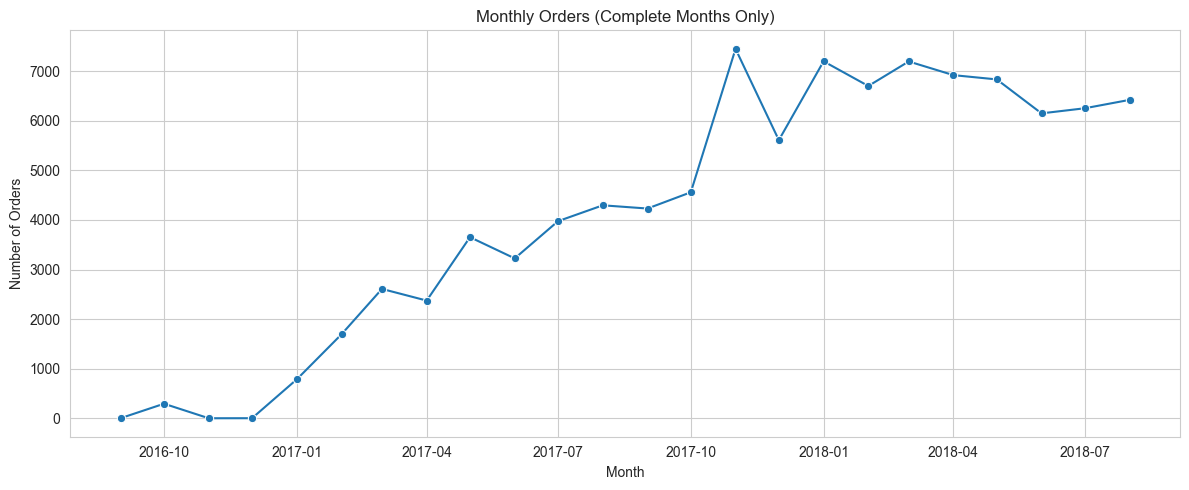

In [8]:
df["order_date"] = pd.to_datetime(
    df["order_date"],
    errors="coerce",
    utc=False)

last_order_date = df["order_date"].max()
last_complete_month_start = (
    last_order_date.to_period("M").to_timestamp()
)

orders_per_month = (
    df
    .set_index("order_date")
    .resample("MS")
    .size()
    .reset_index(name="orders")
)

orders_per_month = orders_per_month[
    orders_per_month["order_date"] < last_complete_month_start
]

sns.set_style("whitegrid")

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=orders_per_month,
    x="order_date",
    y="orders",
    marker="o"
)

plt.title("Monthly Orders (Complete Months Only)")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

In [9]:
df["customer_city"].value_counts().head(10)

customer_city
sao paulo                15332
rio de janeiro            6829
belo horizonte            2752
brasilia                  2125
curitiba                  1504
campinas                  1426
porto alegre              1380
salvador                  1238
guarulhos                 1168
sao bernardo do campo      925
Name: count, dtype: int64

In [10]:
data_map = {
    "city": [
        "São Paulo", "Rio de Janeiro", "Belo Horizonte", "Brasília",
        "Curitiba", "Campinas", "Porto Alegre", "Salvador",
        "Guarulhos", "São Bernardo do Campo"
    ],
    "clients": [15332, 6829, 2752, 2125, 1504, 1426, 1380, 1238, 1168, 925],
    "lat": [
        -23.5505, -22.9068, -19.9167, -15.7939,
        -25.4284, -22.9056, -30.0346, -12.9777,
        -23.4543, -23.6914
    ],
    "lon": [
        -46.6333, -43.1729, -43.9345, -47.8828,
        -49.2733, -47.0608, -51.2177, -38.5016,
        -46.5333, -46.5646
    ]
}

df_map = pd.DataFrame(data_map)

m = folium.Map(location=[-15.8, -47.9], zoom_start=4)

for _, row in df_map.iterrows():
    folium.CircleMarker(
        location=[row.lat, row.lon],
        radius=row.clients / 1000,
        popup=f"{row.city}: {row.clients}",
        color="red",
        fill=True,
        fill_opacity=0.6
    ).add_to(m)

m.save("clients_brazil_map.html")

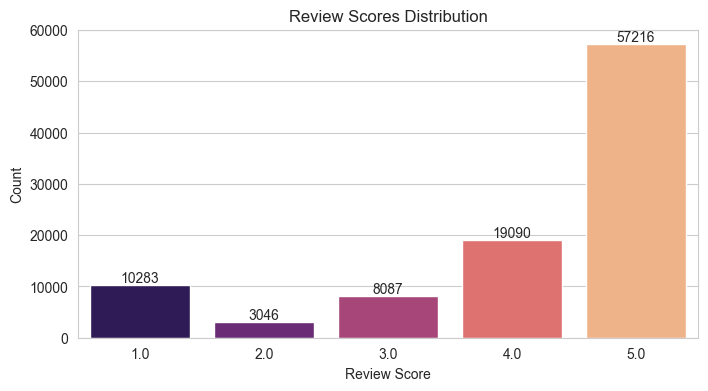

In [11]:
score_counts = df['review_score'].value_counts().sort_index()

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=score_counts.index, y=score_counts.values, palette="magma")

for i, count in enumerate(score_counts.values):
    ax.text(i, count + max(score_counts.values)*0.01, str(count), ha='center')

plt.title("Review Scores Distribution")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()

C:\Users\jfurs\AppData\Local\Temp\ipykernel_19580\1250840144.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("viridis")


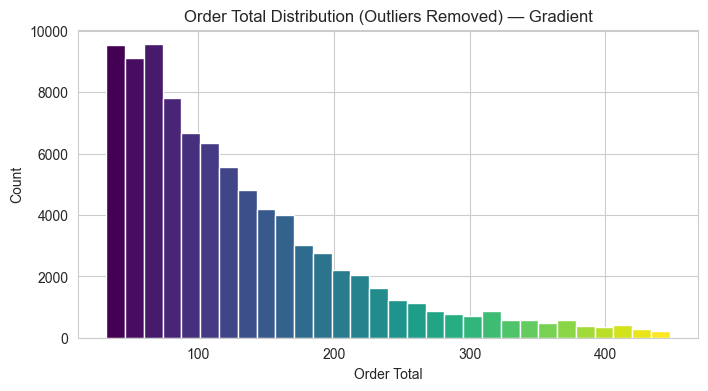

In [12]:
lower = df['order_total'].quantile(0.05)
upper = df['order_total'].quantile(0.95)
price_filtered = df[(df['order_total'] >= lower) & (df['order_total'] <= upper)]

counts, bins = np.histogram(price_filtered['order_total'], bins=30)

cmap = get_cmap("viridis")  
colors = cmap(np.linspace(0, 1, len(bins)-1))  

plt.figure(figsize=(8, 4))
for i in range(len(counts)):
    plt.bar(bins[i], counts[i], width=bins[i+1]-bins[i], color=colors[i], align='edge')

plt.title("Order Total Distribution (Outliers Removed) — Gradient")
plt.xlabel("Order Total")
plt.ylabel("Count")
plt.show()

## DATA PREPARATION

In [13]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["order_estimated_delivery_date"] = pd.to_datetime(df["order_estimated_delivery_date"])
df["delivery_date"] = pd.to_datetime(df["delivery_date"])

today_date = df['order_date'].max() + pd.Timedelta(days=1)

df.dropna(subset=["order_date", "order_total", "delivery_date"], inplace=True)

df["review_score"] = df["review_score"].fillna(df["review_score"].mean())

In [14]:
df["delay_days"] = df["delivery_date"] - df["order_estimated_delivery_date"]

In [15]:
df.to_csv("cleaned_data.csv", index=False)